In [1]:
##   from version in May 2025:
##   "looking back" in time during training and inference, window size of 8 years
''' added a MultiKernelConv1d to adapt and try different kernels'''
''' added a focal loss fuction, which focuses learning on harder, misclassified samples'''
''' here: added a temporal self-attention class'''
''' here: proba > 0.5'''
''' use as predictors the RED, SW1, SW2, NBR, NDVI, TCB, TCG, TCW, DIn'''
''' also test using only Landsat bands'''

'''changes:
- minmax Scaler on each channel
- time dropout
- computing f1 for the whole epoch, not for every batch and then averaging
- printing test statistics with train statistics (commonly done this way)
- nan values (yet to do)
- positional encoding (yet to do)'''


'changes:\n- minmax Scaler on each channel\n- time dropout\n- computing f1 for the whole epoch, not for every batch and then averaging\n- printing test statistics with train statistics (commonly done this way)\n- nan values (yet to do)\n- positional encoding (yet to do)'

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split
import random
pd.set_option('display.float_format', '{:.2f}'.format)
np.set_printoptions(suppress=True)

import os
print(os.getcwd())

/home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/Code_Alba


     country  plotid  year class_level1 class_level2  new_class2_v5  uniqueid  \
fid                                                                             
0    albania       1  1985        treed        treed              0  albania1   
1    albania       1  1986        treed        treed              0  albania1   
2    albania       1  1987        treed        treed              0  albania1   
3    albania       1  1988        treed        treed              0  albania1   
4    albania       1  1989        treed        treed              0  albania1   

     numerical_id        x           y      Tile_ID     merged_id    BLU  \
fid                                                                        
0               1 20660.18 -1493987.48  X0036_Y0032  1985albania1   5.00   
1               1 20660.18 -1493987.48  X0036_Y0032  1986albania1 293.00   
2               1 20660.18 -1493987.48  X0036_Y0032  1987albania1 161.00   
3               1 20660.18 -1493987.48  X0036_Y0032 

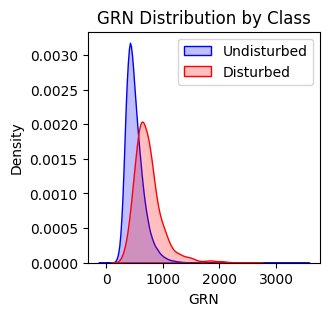

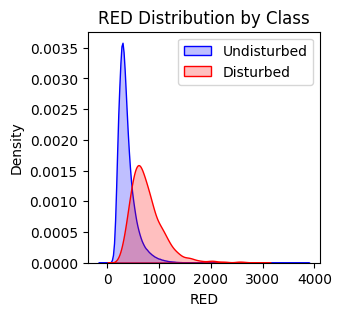

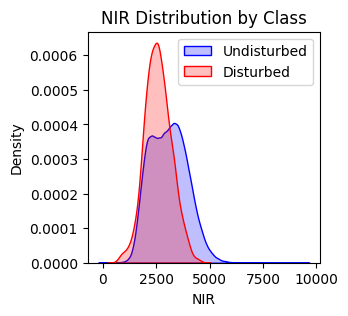

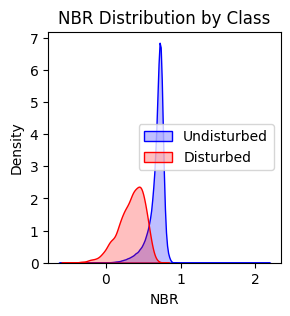

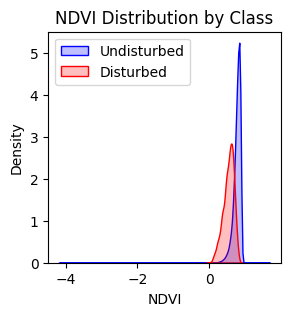

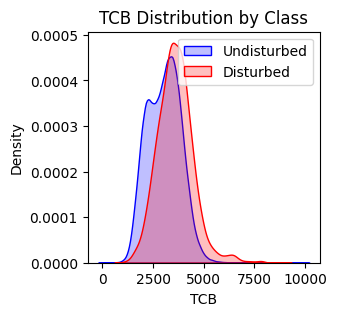

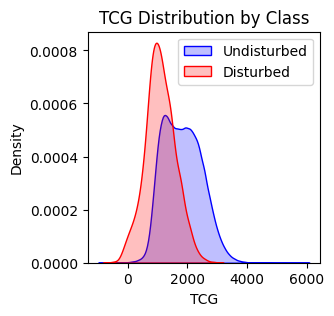

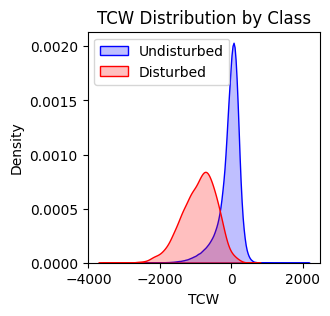

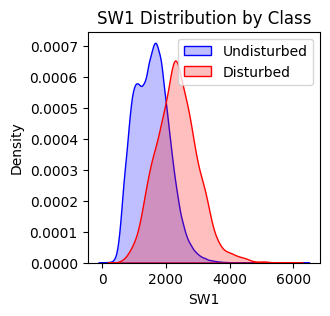

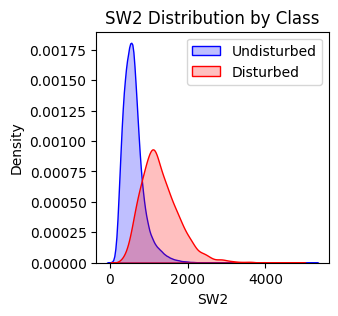

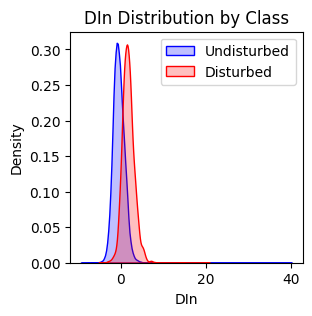

class_level1
treed          510211
disturbance      8711
non-treed        5850
Name: count, dtype: int64


In [3]:
# # #  option 2
df = pd.read_csv('/home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/Data/Training/forest_dataset_timesync_alltiles_landsatbands_indices3_classes_ed5_calibration.csv',index_col=0, sep=';')
print(df.head())

# create disturbance labels
df['class'] = df['class_level1'].apply(lambda x: 1 if x == 'disturbance' else 0)
print(df.head(10))

import seaborn as sns
import matplotlib.pyplot as plt

# Plot distributions for each feature
features = ['GRN', 'RED', 'NIR', 'NBR', 'NDVI', 'TCB', 'TCG', 'TCW', 'SW1', 'SW2','DIn']

for feature in features:
    plt.figure(figsize=(3, 3))
    sns.kdeplot(df[df['new_class2_v5'] == 0][feature], label='Undisturbed', fill=True, color='blue')
    sns.kdeplot(df[df['new_class2_v5'] == 1][feature], label='Disturbed', fill=True, color='red')
    plt.title(f"{feature} Distribution by Class")
    plt.legend()
    plt.show()


## filter doubtful samples
df = df[~((df['class_level1'] == 'treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'treed') & (df['NDVI'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NDVI'] < 0.5))]
df = df[~((['class_level1'] == 'disturbance') & (df['NBR'] > 0.5))]
df = df[~((['class_level1'] == 'disturbance') & (df['NDVI'] > 0.5))]

# Count the number of samples per class
class_counts = df['class_level1'].value_counts()
print(class_counts)


In [4]:
import torch
from torch.optim import Adam
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split

# Check CUDA availability
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Current Device:", torch.cuda.current_device())
    print("Device Name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    torch.cuda.empty_cache()

CUDA Available: True
Current Device: 0
Device Name: NVIDIA GeForce RTX 3090


In [5]:


# Check CUDA availability
if not torch.cuda.is_available():
    print("CUDA is unavailable. Using CPU.")
    device = torch.device("cpu")
else:
    print("CUDA is available!")
    device = torch.device("cuda:0")
    torch.cuda.empty_cache()

# Test a small tensor on the GPU
try:
    x = torch.rand(3, 3).to(device)
    print("GPU Test Passed")
except RuntimeError as e:
    print(f"GPU Test Failed: {e}")

# Print GPU memory info
if torch.cuda.is_available():
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"Total GPU Memory: {gpu_props.total_memory / (1024**3):.2f} GB")
    print(f"Allocated Memory: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
    print(f"Cached Memory: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

CUDA is available!
GPU Test Passed
Total GPU Memory: 23.57 GB
Allocated Memory: 0.00 GB
Cached Memory: 0.00 GB


In [ ]:
##   from version in May 2025:
##   "looking back" in time during training and inference, window size of 8 years
''' added a MultiKernelConv1d to adapt and try different kernels'''
''' added a focal loss fuction, which focuses learning on harder, misclassified samples'''
''' here: added a temporal self-attention class'''
''' here: proba > 0.5'''
''' use as predictors the RED, SW1, SW2, NBR, NDVI, TCB, TCG, TCW, DIn'''
'''only using the past (backward temporal context). This is classic autoregressive-style time series modeling.'''

import pandas as pd
import numpy as np
import numpy as numpy
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

samples_data = []
samples_label = []

window_size = 8 # 16
missing = 0

for _, group in tqdm(df.groupby('uniqueid')):
    group = group.sort_values('year')
    if len(group) < 30:
        missing += 1
        continue
    #data = group[['NIR', 'SW1', 'SW2','NBR','NDVI','TCB','TCG','TCW','DIn']].diff().fillna(0)
    # Select the features you want to include (e.g., NBR, NDVI, TCW, SWIR) 
    features = ['RED', 'SW1', 'SW2', 'NBR', 'NDVI', 'TCG', 'TCW', 'DIn']           #### TRY ADDING ALSO NIT AND TCB!!!
    
    # Prepare the data using these features
    #data = group[['NBR']].fillna(0)
    data = group[features].fillna(0) 
    '''data = (
    group
    .groupby('uniqueid')[features]
    .apply(lambda g: g.interpolate(method='linear', limit_direction='both'))
    .reset_index(drop=True)
)   '''
    label = group['new_class2_v5'].to_numpy()

    # Apply a rolling window of size to the data with slicing
    data = numpy.array([data[i:i+window_size].to_numpy() for i in range(len(data)-window_size+1)])
    label = numpy.array([label[i:i+window_size] for i in range(len(label)-window_size+1)])

    #data = data.reshape((1,data.shape[0],data.shape[1]))
    #label = label.reshape((1,len(label)))

    samples_data.append(data)
    samples_label.append(label)

X = samples_data
y = samples_label
print("missing")
print(missing)

import numpy as np
flat_labels = np.concatenate(samples_label).flatten()
print("Class balance:", np.bincount(flat_labels.astype(int)))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)


'''these arrays have different shapes'''
# Flatten the first dimension
X_train_new = np.concatenate(X_train, axis=0)
X_test_new = np.concatenate(X_test, axis=0)
y_train_new = np.concatenate(y_train, axis=0)
y_test_new = np.concatenate(y_test, axis=0)

# Compute class weights
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
y_train_flat = y_train_new.flatten().astype(int)
weights = compute_class_weight('balanced', classes=classes, y=y_train_flat)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f"Class weights: {class_weights}")

# Shuffle the data
def unison_shuffled_copies(a, b):
    assert len(a) == len(b)
    p = np.random.permutation(len(a))
    return a[p], b[p]

X_train_new, y_train_new = unison_shuffled_copies(X_train_new, y_train_new)
X_test_new, y_test_new = unison_shuffled_copies(X_test_new, y_test_new)

'''# Normalize the data
min_train = X_train_new.min()
max_train = X_train_new.max()
min_test = X_test_new.min()
max_test = X_test_new.max()

# we don't want to use any additional information from the test set for the normalization
X_train_scaled = (X_train_new - min_train) / (max_train - min_train)
X_test_scaled = (X_test_new - min_train) / (max_train - min_train)'''

''' use minmax Scaler on each channel seperateley'''

# Let's see what we're dealing with
print("Debugging data structure:")
print(f"X_train type: {type(X_train)}")
print(f"X_train length: {len(X_train)}")

# Check shapes of first few elements
print("\nFirst 5 elements shapes:")
for i in range(min(5, len(X_train))):
    element = X_train[i]
    print(f"Element {i}: type={type(element)}, shape={element.shape if hasattr(element, 'shape') else len(element)}")

# Check if all elements have the same shape
shapes = []
for i in range(min(100, len(X_train))):  # Check first 100
    element = X_train[i]
    if hasattr(element, 'shape'):
        shapes.append(element.shape)
    else:
        shapes.append(len(element))

unique_shapes = list(set(shapes))
print(f"\nUnique shapes found: {unique_shapes}")
print(f"Number of different shapes: {len(unique_shapes)}")

from sklearn.preprocessing import MinMaxScaler
import numpy as np

X_train = np.array(X_train_new, dtype=np.float32)
X_test = np.array(X_test_new, dtype=np.float32) 

# Replace your current scaling code with this:
scaler = MinMaxScaler(feature_range=(0, 1))

# Reshape to 2D for scaling
X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

# Scale (fit only on training data!)
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

# Reshape back to original 3D shape
X_train_scaled = X_train_scaled_2d.reshape(X_train.shape)
X_test_scaled = X_test_scaled_2d.reshape(X_test.shape)

print(f"Scaling complete! Train range: [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")

# Prepare data for PyTorch
X_train_tensor = torch.Tensor(X_train_scaled).permute(0, 2, 1)  # (batch, time_steps, features)
X_test_tensor = torch.Tensor(X_test_scaled).permute(0, 2, 1)
y_train_tensor = torch.Tensor(y_train_new)
y_test_tensor = torch.Tensor(y_test_new)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader for training and validation
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True, num_workers=1, persistent_workers=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False, num_workers=1, persistent_workers=True)

# Define the multi-kernel conv block first
'''is a multi-scale convolutional block. It applies several 1D convolutions in parallel with different kernel sizes (e.g., 3, 5, 7) 
and concatenates their outputs. It lets the network capture temporal patterns at multiple scales:
    Sharp changes (e.g., fire in 1 year),
    Gradual changes (e.g., slow dieback over several years).'''

class TemporalDropout(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.dropout_rate = dropout_rate

    def forward(self, x):
        # x shape: (B, C, T)
        if not self.training or self.dropout_rate == 0.0:
            return x

        B, C, T = x.shape
        mask = (torch.rand(B, T, device=x.device) > self.dropout_rate).float()
        mask = mask.unsqueeze(1)  # shape: (B, 1, T)
        return x * mask

class MultiKernelConv1d(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(MultiKernelConv1d, self).__init__()
        self.conv3 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3)
        self.norm = nn.LayerNorm(out_channels*3)

    def forward(self, x):
        x3 = self.conv3(x)
        x5 = self.conv5(x)
        x7 = self.conv7(x)
        x_cat = torch.cat([x3, x5, x7], dim=1)  # Concatenate channel-wise
        x_cat = self.norm(x_cat.permute(0, 2, 1)).permute(0, 2, 1)
        return F.relu(x_cat)

class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # weight for class 1 (disturbance)
        self.gamma = gamma  # focusing parameter
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Compute binary cross entropy loss without reduction
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')

        # Convert logits to probabilities
        pt = torch.exp(-BCE_loss)  # pt is the probability of correct prediction

        # Compute focal loss
        loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss

        return loss.mean() if self.reduction == 'mean' else loss.sum()

class TemporalSelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.scale = embed_dim ** -0.5

    def forward(self, x):
        # x: (batch, channels, time)
        x = x.permute(0, 2, 1)  # -> (batch, time, channels)
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        attn_weights = torch.softmax((Q @ K.transpose(-2, -1)) * self.scale, dim=-1)
        attended = attn_weights @ V

        return attended.permute(0, 2, 1)  # -> (batch, channels, time)
        

class AlbasUNet(nn.Module):
    def __init__(self):
        super(AlbasUNet, self).__init__()

        n_ch1 = 16
        n_ch2 = 32
        n_ch3 = 64
        n_ch_bottleneck = 128

        # Multi-kernel convs output 3x channels
        self.dropout = TemporalDropout(dropout_rate=0.2)
        self.conv1 = MultiKernelConv1d(in_channels=8, out_channels=n_ch1)  # Outputs 16*3=48 channels
        self.pool1 = nn.AvgPool1d(kernel_size=2)

        self.conv2 = MultiKernelConv1d(in_channels=48, out_channels=n_ch2)  # Outputs 32*3=96 channels
        self.pool2 = nn.AvgPool1d(kernel_size=2)

        self.conv3 = MultiKernelConv1d(in_channels=96, out_channels=n_ch3)  # Outputs 64*3=192 channels
        self.pool3 = nn.AvgPool1d(kernel_size=2)

        self.conv4 = nn.Conv1d(in_channels=192, out_channels=n_ch_bottleneck, kernel_size=1)
        self.attention = TemporalSelfAttention(embed_dim=n_ch_bottleneck)

        # Upsampling layers
        self.up3 = nn.ConvTranspose1d(in_channels=n_ch_bottleneck, out_channels=192, kernel_size=2, stride=2)
        self.up2 = nn.ConvTranspose1d(in_channels=192*2, out_channels=96, kernel_size=2, stride=2)
        self.up1 = nn.ConvTranspose1d(in_channels=96*2, out_channels=48, kernel_size=2, stride=2)

        self.out_conv = nn.Conv1d(in_channels=48*2, out_channels=1, kernel_size=1)
    
    def forward(self, x):
        x = self.dropout(x)
        x1_features = self.conv1(x)
        x1 = self.pool1(x1_features)

        x2_features = self.conv2(x1)
        x2 = self.pool2(x2_features)

        x3_features = self.conv3(x2)
        x3 = self.pool3(x3_features)

        x4 = F.relu(self.conv4(x3))  # Bottleneck features

        x4 = self.attention(x4)  # [batch, channels, time] in, returns same shape


        x_up3 = self.up3(x4)
        if x_up3.shape[2] != x3.shape[2]:
            x3 = F.pad(x3, (0, x_up3.shape[2] - x3.shape[2]))
        x_up2 = self.up2(torch.cat([x_up3, x3], dim=1))
        if x_up2.shape[2] != x2.shape[2]:
            x2 = F.pad(x2, (0, x_up2.shape[2] - x2.shape[2]))
        x_up1 = self.up1(torch.cat([x_up2, x2], dim=1))
        if x_up1.shape[2] != x1.shape[2]:
            x1 = F.pad(x1, (0, x_up1.shape[2] - x1.shape[2]))

        out = self.out_conv(torch.cat([x_up1, x1], dim=1))
        return out.squeeze(1)

        

# Train the U-Net model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AlbasUNet().to(device)
optimizer = Adam(model.parameters())
from torch.optim import AdamW

#optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)


from sklearn.metrics import f1_score
# Compute loss
# Count positives and negatives in training data
num_positives = y_train_tensor.sum()
num_negatives = len(y_train_tensor.view(-1)) - num_positives
        
# Compute pos_weight
pos_weight = num_negatives / (num_positives + 1e-6)  # Avoid div by zero
class_weights = torch.tensor([1.0, pos_weight], device=device)  # Not used directly, just for reference
# Define loss with pos_weight
'''loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)'''
#  or for focal loss:
'''Higher gamma penalizes easy examples more.
Slightly increasing alpha biases toward rare class (disturbance).'''
loss_fn = FocalLoss(alpha=2.0, gamma=2.0)  # You can tune alpha and gamma



'''f1 calculation over whole epoch not just one batch'''

def train_epoch_full_f1(model, train_loader, optimizer, device, loss_fn):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_hat = model(x)
        loss = loss_fn(y_hat, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        probs = torch.sigmoid(y_hat)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())

    all_preds = torch.cat(all_preds).view(-1).numpy()
    all_labels = torch.cat(all_labels).view(-1).numpy()

    train_f1 = f1_score(all_labels, all_preds, zero_division=0)
    train_acc = accuracy_score(all_labels, all_preds)

    avg_loss = total_loss / len(train_loader)
    return avg_loss, train_acc,train_f1


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_model(model, data_loader, device, criterion, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    total_samples = 0
    
    with torch.no_grad():
        for batch_data, batch_labels in data_loader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_data)  # shape: (batch_size, seq_len) or (batch_size, seq_len, 1)

            # If output has extra dim, squeeze it (e.g., (B, T, 1) -> (B, T))
            if outputs.dim() == 3 and outputs.size(2) == 1:
                outputs = outputs.squeeze(2)

            # Compute loss over all timesteps and all samples in batch
            loss = criterion(outputs, batch_labels)
            batch_size = batch_data.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            # Convert predictions to binary using sigmoid and threshold
            preds = (torch.sigmoid(outputs) > threshold).cpu().numpy().astype(int)
            labels = batch_labels.cpu().numpy().astype(int)

            # Flatten predictions and labels to 1D arrays for metric calculations
            all_preds.extend(preds.reshape(-1).tolist())
            all_labels.extend(labels.reshape(-1).tolist())
    
    avg_loss = total_loss / total_samples
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    val_acc = accuracy_score(y_true, y_pred)
    val_f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)
    val_precision = precision_score(y_true, y_pred, average='binary', zero_division=0)
    val_recall = recall_score(y_true, y_pred, average='binary', zero_division=0)
    
    return y_true, y_pred, avg_loss, val_acc, val_f1, val_precision, val_recall


best_val_f1 = 0.0
best_model_path = "best_model_val_f1.pth"

# Train for several epochs
for epoch in range(30):
    train_loss, train_acc, train_f1 = train_epoch_full_f1(model, train_loader, optimizer, device, loss_fn)  # 🔧 CHANGED
    y_true_val, y_pred_val, val_loss, val_acc, val_f1, val_precision, val_recall = evaluate_model(model, val_loader, device, loss_fn)
    print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}')
    print(f'Validation Loss: {val_loss:.4f}, Validation Acc: {val_acc:.4f}, Validation F1: {val_f1:.4f}')

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"New best validation F1: {best_val_f1:.4f}! Model saved.")





'''def evaluate_model(model, data_loader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            all_preds.append(preds.view(-1).cpu())
            all_labels.append(y.view(-1).cpu())

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()

    print("Evaluation Metrics:")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred, zero_division=0):.4f}")'''
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_val, y_pred_val))
print("\nClassification Report:")
print(classification_report(y_true_val, y_pred_val , zero_division=0))

# Save model weights
# torch.save(model.state_dict(), "/.../ai4forest/AI_inference/models_unet/1dunet_w8_prob05_v1.pth")

100%|██████████| 16954/16954 [00:14<00:00, 1194.96it/s]


missing
2551
Class balance: [2961016    8984]
Class weights: tensor([  0.5016, 160.1655], device='cuda:0')
Debugging data structure:
X_train type: <class 'list'>
X_train length: 9650

First 5 elements shapes:
Element 0: type=<class 'numpy.ndarray'>, shape=(27, 8, 8)
Element 1: type=<class 'numpy.ndarray'>, shape=(26, 8, 8)
Element 2: type=<class 'numpy.ndarray'>, shape=(23, 8, 8)
Element 3: type=<class 'numpy.ndarray'>, shape=(26, 8, 8)
Element 4: type=<class 'numpy.ndarray'>, shape=(27, 8, 8)

Unique shapes found: [(23, 8, 8), (24, 8, 8), (25, 8, 8), (26, 8, 8), (27, 8, 8)]
Number of different shapes: 5
Scaling complete! Train range: [0.000, 1.000]
Epoch 0, Train Loss: 0.0087, Train Acc: 0.9970, Train F1: 0.1363
Validation Loss: 0.0054, Validation Acc: 0.9975, Validation F1: 0.2854
New best validation F1: 0.2854! Model saved.
Epoch 1, Train Loss: 0.0063, Train Acc: 0.9973, Train F1: 0.3094
Validation Loss: 0.0041, Validation Acc: 0.9976, Validation F1: 0.4041
New best validation F1: 0

In [8]:
''' result from 1dunet_w8_prob05_v1'''

Evaluation Metrics:
Accuracy:  0.9985
Precision: 0.7301
Recall:    0.6542
F1 Score:  0.6900

Confusion Matrix:
[[555456    335]
 [   479    906]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    555791
         1.0       0.73      0.65      0.69      1385

    accuracy                           1.00    557176
   macro avg       0.86      0.83      0.84    557176
weighted avg       1.00      1.00      1.00    557176




IndentationError: unindent does not match any outer indentation level (<string>, line 16)

In [ ]:
''' SEE ALSO PLOT OF TRAINIGN AND VAL LOSS'''

Evaluation Metrics:
Accuracy:  0.9986
Precision: 0.8174
Recall:    0.5625
F1 Score:  0.6664

Confusion Matrix:
[[555617    174]
 [   606    779]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    555791
         1.0       0.82      0.56      0.67      1385

    accuracy                           1.00    557176
   macro avg       0.91      0.78      0.83    557176
weighted avg       1.00      1.00      1.00    557176



In [7]:
##   from version in May 2025:
##   "looking back" in time during training and inference, window size of 8 years
''' added a MultiKernelConv1d to adapt and try different kernels'''
''' added a focal loss fuction, which focuses learning on harder, misclassified samples'''
''' here: added a temporal self-attention class'''
''' here: proba > 0.5'''
''' use as predictors the RED, SW1, SW2, NBR, NDVI, TCB, TCG, TCW, DIn'''
'''only using the past (backward temporal context). This is classic autoregressive-style time series modeling.'''

import pandas as pd
import numpy as np
import numpy as numpy
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

samples_data = []
samples_label = []

window_size = 8 # 16
missing = 0

for _, group in tqdm(df.groupby('uniqueid')):
    group = group.sort_values('year')
    if len(group) < 30:
        missing += 1
        continue
    #data = group[['NIR', 'SW1', 'SW2','NBR','NDVI','TCB','TCG','TCW','DIn']].diff().fillna(0)
    # Select the features you want to include (e.g., NBR, NDVI, TCW, SWIR) 
    features = ['BLU', 'GRN', 'RED', 'NIR', 'SW1', 'SW2']           #### TRY ADDING ALSO NIT AND TCB!!!
    
    # Prepare the data using these features
    #data = group[['NBR']].fillna(0)
    data = group[features].fillna(0) 
    label = group['new_class2_v5'].to_numpy()

    # Apply a rolling window of size to the data with slicing
    data = numpy.array([data[i:i+window_size].to_numpy() for i in range(len(data)-window_size+1)])
    label = numpy.array([label[i:i+window_size] for i in range(len(label)-window_size+1)])

    #data = data.reshape((1,data.shape[0],data.shape[1]))
    #label = label.reshape((1,len(label)))

    samples_data.append(data)
    samples_label.append(label)

X = samples_data
y = samples_label
print("missing")
print(missing)

import numpy as np
flat_labels = np.concatenate(samples_label).flatten()
print("Class balance:", np.bincount(flat_labels.astype(int)))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)


'''these arrays have different shapes'''
# Flatten the first dimension
X_train_new = np.concatenate(X_train, axis=0)
X_test_new = np.concatenate(X_test, axis=0)
y_train_new = np.concatenate(y_train, axis=0)
y_test_new = np.concatenate(y_test, axis=0)

# Compute class weights
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
y_train_flat = y_train_new.flatten().astype(int)
weights = compute_class_weight('balanced', classes=classes, y=y_train_flat)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f"Class weights: {class_weights}")

# Shuffle the data
def unison_shuffled_copies(a, b):
    assert len(a) == len(b)
    p = np.random.permutation(len(a))
    return a[p], b[p]

X_train_new, y_train_new = unison_shuffled_copies(X_train_new, y_train_new)
X_test_new, y_test_new = unison_shuffled_copies(X_test_new, y_test_new)

'''# Normalize the data
min_train = X_train_new.min()
max_train = X_train_new.max()
min_test = X_test_new.min()
max_test = X_test_new.max()

# we don't want to use any additional information from the test set for the normalization
X_train_scaled = (X_train_new - min_train) / (max_train - min_train)
X_test_scaled = (X_test_new - min_train) / (max_train - min_train)'''

''' use minmax Scaler on each channel seperateley'''

# Let's see what we're dealing with
print("Debugging data structure:")
print(f"X_train type: {type(X_train)}")
print(f"X_train length: {len(X_train)}")

# Check shapes of first few elements
print("\nFirst 5 elements shapes:")
for i in range(min(5, len(X_train))):
    element = X_train[i]
    print(f"Element {i}: type={type(element)}, shape={element.shape if hasattr(element, 'shape') else len(element)}")

# Check if all elements have the same shape
shapes = []
for i in range(min(100, len(X_train))):  # Check first 100
    element = X_train[i]
    if hasattr(element, 'shape'):
        shapes.append(element.shape)
    else:
        shapes.append(len(element))

unique_shapes = list(set(shapes))
print(f"\nUnique shapes found: {unique_shapes}")
print(f"Number of different shapes: {len(unique_shapes)}")

from sklearn.preprocessing import MinMaxScaler
import numpy as np

X_train = np.array(X_train_new, dtype=np.float32)
X_test = np.array(X_test_new, dtype=np.float32) 

# Replace your current scaling code with this:
scaler = MinMaxScaler(feature_range=(0, 1))

# Reshape to 2D for scaling
X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

# Scale (fit only on training data!)
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

# Reshape back to original 3D shape
X_train_scaled = X_train_scaled_2d.reshape(X_train.shape)
X_test_scaled = X_test_scaled_2d.reshape(X_test.shape)

print(f"Scaling complete! Train range: [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")

# Prepare data for PyTorch
X_train_tensor = torch.Tensor(X_train_scaled).permute(0, 2, 1)  # (batch, time_steps, features)
X_test_tensor = torch.Tensor(X_test_scaled).permute(0, 2, 1)
y_train_tensor = torch.Tensor(y_train_new)
y_test_tensor = torch.Tensor(y_test_new)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader for training and validation
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True, num_workers=1, persistent_workers=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False, num_workers=1, persistent_workers=True)

# Define the multi-kernel conv block first
'''is a multi-scale convolutional block. It applies several 1D convolutions in parallel with different kernel sizes (e.g., 3, 5, 7) 
and concatenates their outputs. It lets the network capture temporal patterns at multiple scales:
    Sharp changes (e.g., fire in 1 year),
    Gradual changes (e.g., slow dieback over several years).'''

class TemporalDropout(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.dropout_rate = dropout_rate

    def forward(self, x):
        # x shape: (B, C, T)
        if not self.training or self.dropout_rate == 0.0:
            return x

        B, C, T = x.shape
        mask = (torch.rand(B, T, device=x.device) > self.dropout_rate).float()
        mask = mask.unsqueeze(1)  # shape: (B, 1, T)
        return x * mask

class MultiKernelConv1d(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(MultiKernelConv1d, self).__init__()
        self.conv3 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3)

        self.norm = nn.LayerNorm(out_channels*3)

    def forward(self, x):
        x3 = self.conv3(x)
        x5 = self.conv5(x)
        x7 = self.conv7(x)
        x_cat = torch.cat([x3, x5, x7], dim=1)  # Concatenate channel-wise
        x_cat = self.norm(x_cat.permute(0, 2, 1)).permute(0, 2, 1)

        return F.relu(x_cat)

class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # weight for class 1 (disturbance)
        self.gamma = gamma  # focusing parameter
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Compute binary cross entropy loss without reduction
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')

        # Convert logits to probabilities
        pt = torch.exp(-BCE_loss)  # pt is the probability of correct prediction

        # Compute focal loss
        loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss

        return loss.mean() if self.reduction == 'mean' else loss.sum()

class TemporalSelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.scale = embed_dim ** -0.5

    def forward(self, x):
        # x: (batch, channels, time)
        x = x.permute(0, 2, 1)  # -> (batch, time, channels)
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        attn_weights = torch.softmax((Q @ K.transpose(-2, -1)) * self.scale, dim=-1)
        attended = attn_weights @ V

        return attended.permute(0, 2, 1)  # -> (batch, channels, time)
        

class AlbasUNet(nn.Module):
    def __init__(self):
        super(AlbasUNet, self).__init__()

        n_ch1 = 16
        n_ch2 = 32
        n_ch3 = 64
        n_ch_bottleneck = 128

        # Multi-kernel convs output 3x channels
        self.dropout = TemporalDropout(dropout_rate=0.2)
        self.conv1 = MultiKernelConv1d(in_channels=6, out_channels=n_ch1)  # Outputs 16*3=48 channels
        self.pool1 = nn.AvgPool1d(kernel_size=2)

        self.conv2 = MultiKernelConv1d(in_channels=48, out_channels=n_ch2)  # Outputs 32*3=96 channels
        self.pool2 = nn.AvgPool1d(kernel_size=2)

        self.conv3 = MultiKernelConv1d(in_channels=96, out_channels=n_ch3)  # Outputs 64*3=192 channels
        self.pool3 = nn.AvgPool1d(kernel_size=2)

        self.conv4 = nn.Conv1d(in_channels=192, out_channels=n_ch_bottleneck, kernel_size=1)
        self.attention = TemporalSelfAttention(embed_dim=n_ch_bottleneck)

        # Upsampling layers
        self.up3 = nn.ConvTranspose1d(in_channels=n_ch_bottleneck, out_channels=192, kernel_size=2, stride=2)
        self.up2 = nn.ConvTranspose1d(in_channels=192*2, out_channels=96, kernel_size=2, stride=2)
        self.up1 = nn.ConvTranspose1d(in_channels=96*2, out_channels=48, kernel_size=2, stride=2)

        self.out_conv = nn.Conv1d(in_channels=48*2, out_channels=1, kernel_size=1)
    
    def forward(self, x):
        x = self.dropout(x)
        x1_features = self.conv1(x)
        x1 = self.pool1(x1_features)

        x2_features = self.conv2(x1)
        x2 = self.pool2(x2_features)

        x3_features = self.conv3(x2)
        x3 = self.pool3(x3_features)

        x4 = F.relu(self.conv4(x3))  # Bottleneck features

        x4 = self.attention(x4)  # [batch, channels, time] in, returns same shape


        x_up3 = self.up3(x4)
        if x_up3.shape[2] != x3.shape[2]:
            x3 = F.pad(x3, (0, x_up3.shape[2] - x3.shape[2]))
        x_up2 = self.up2(torch.cat([x_up3, x3], dim=1))
        if x_up2.shape[2] != x2.shape[2]:
            x2 = F.pad(x2, (0, x_up2.shape[2] - x2.shape[2]))
        x_up1 = self.up1(torch.cat([x_up2, x2], dim=1))
        if x_up1.shape[2] != x1.shape[2]:
            x1 = F.pad(x1, (0, x_up1.shape[2] - x1.shape[2]))

        out = self.out_conv(torch.cat([x_up1, x1], dim=1))
        return out.squeeze(1)

        

# Train the U-Net model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AlbasUNet().to(device)
optimizer = Adam(model.parameters())
from torch.optim import AdamW

#optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)


from sklearn.metrics import f1_score
# Compute loss
# Count positives and negatives in training data
num_positives = y_train_tensor.sum()
num_negatives = len(y_train_tensor.view(-1)) - num_positives
        
# Compute pos_weight
pos_weight = num_negatives / (num_positives + 1e-6)  # Avoid div by zero
class_weights = torch.tensor([1.0, pos_weight], device=device)  # Not used directly, just for reference
# Define loss with pos_weight
'''loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)'''
#  or for focal loss:
'''Higher gamma penalizes easy examples more.
Slightly increasing alpha biases toward rare class (disturbance).'''
loss_fn = FocalLoss(alpha=2.0, gamma=2.0)  # You can tune alpha and gamma


'''f1 calculation over whole epoch not just one batch'''

def train_epoch_full_f1(model, train_loader, optimizer, device, loss_fn):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_hat = model(x)
        loss = loss_fn(y_hat, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        probs = torch.sigmoid(y_hat)
        preds = (probs > 0.5).float()

        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())

    all_preds = torch.cat(all_preds).view(-1).numpy()
    all_labels = torch.cat(all_labels).view(-1).numpy()

    train_f1 = f1_score(all_labels, all_preds, zero_division=0)
    train_acc = accuracy_score(all_labels, all_preds)

    avg_loss = total_loss / len(train_loader)
    return avg_loss, train_acc,train_f1


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_model(model, data_loader, device, criterion, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0.0
    total_samples = 0
    
    with torch.no_grad():
        for batch_data, batch_labels in data_loader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_data)  # shape: (batch_size, seq_len) or (batch_size, seq_len, 1)

            # If output has extra dim, squeeze it (e.g., (B, T, 1) -> (B, T))
            if outputs.dim() == 3 and outputs.size(2) == 1:
                outputs = outputs.squeeze(2)

            # Compute loss over all timesteps and all samples in batch
            loss = criterion(outputs, batch_labels)
            batch_size = batch_data.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            # Convert predictions to binary using sigmoid and threshold
            preds = (torch.sigmoid(outputs) > threshold).cpu().numpy().astype(int)
            labels = batch_labels.cpu().numpy().astype(int)

            # Flatten predictions and labels to 1D arrays for metric calculations
            all_preds.extend(preds.reshape(-1).tolist())
            all_labels.extend(labels.reshape(-1).tolist())
    
    avg_loss = total_loss / total_samples
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    val_acc = accuracy_score(y_true, y_pred)
    val_f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)
    val_precision = precision_score(y_true, y_pred, average='binary', zero_division=0)
    val_recall = recall_score(y_true, y_pred, average='binary', zero_division=0)
    
    return y_true, y_pred, avg_loss, val_acc, val_f1, val_precision, val_recall


# Train for several epochs
for epoch in range(60):
    train_loss, train_acc, train_f1 = train_epoch_full_f1(model, train_loader, optimizer, device, loss_fn)  # 🔧 CHANGED
    y_true_val, y_pred_val, val_loss, val_acc, val_f1, val_precision, val_recall = evaluate_model(model, val_loader, device, loss_fn)
    print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}')
    print(f'Validation Loss: {val_loss:.4f}, Validation Acc: {val_acc:.4f}, Validation F1: {val_f1:.4f}')




'''def evaluate_model(model, data_loader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            all_preds.append(preds.view(-1).cpu())
            all_labels.append(y.view(-1).cpu())

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()

    print("Evaluation Metrics:")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred, zero_division=0):.4f}")'''
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_val, y_pred_val))
print("\nClassification Report:")
print(classification_report(y_true_val, y_pred_val , zero_division=0))

# Save model weights
# torch.save(model.state_dict(), "/.../ai4forest/AI_inference/models_unet/1dunet_w8_prob05_v1.pth")

100%|██████████| 16954/16954 [00:13<00:00, 1213.03it/s]


missing
2551
Class balance: [2961016    8984]
Class weights: tensor([  0.5016, 160.1655], device='cuda:0')
Debugging data structure:
X_train type: <class 'list'>
X_train length: 9650

First 5 elements shapes:
Element 0: type=<class 'numpy.ndarray'>, shape=(27, 8, 6)
Element 1: type=<class 'numpy.ndarray'>, shape=(26, 8, 6)
Element 2: type=<class 'numpy.ndarray'>, shape=(23, 8, 6)
Element 3: type=<class 'numpy.ndarray'>, shape=(26, 8, 6)
Element 4: type=<class 'numpy.ndarray'>, shape=(27, 8, 6)

Unique shapes found: [(23, 8, 6), (24, 8, 6), (25, 8, 6), (26, 8, 6), (27, 8, 6)]
Number of different shapes: 5
Scaling complete! Train range: [0.000, 1.000]
Epoch 0, Train Loss: 0.0100, Train Acc: 0.9968, Train F1: 0.0670
Validation Loss: 0.0056, Validation Acc: 0.9973, Validation F1: 0.2177
Epoch 1, Train Loss: 0.0064, Train Acc: 0.9972, Train F1: 0.3228
Validation Loss: 0.0042, Validation Acc: 0.9981, Validation F1: 0.5781
Epoch 2, Train Loss: 0.0056, Train Acc: 0.9976, Train F1: 0.4817
Valid

In [5]:
''' same using window size of 8 base but using only landsat bands'''

##   from version in May 2025:
##   "looking back" in time during training and inference, window size of 8 years
''' added a MultiKernelConv1d to adapt and try different kernels'''
''' added a focal loss fuction, which focuses learning on harder, misclassified samples'''
''' here: added a temporal self-attention class'''
''' here: proba > 0.5'''
''' use as predictors the bands'''

import pandas as pd
import numpy as np
import numpy as numpy
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

samples_data = []
samples_label = []

window_size = 8 # 16
missing = 0

for _, group in tqdm(df.groupby('uniqueid')):
    group = group.sort_values('year')
    if len(group) < 30:
        missing += 1
        continue
    #data = group[['NIR', 'SW1', 'SW2','NBR','NDVI','TCB','TCG','TCW','DIn']].diff().fillna(0)
    # Select the features you want to include (e.g., NBR, NDVI, TCW, SWIR)
    features = ['BLU', 'GRN', 'RED', 'NIR', 'SW1', 'SW2'] 
    
    # Prepare the data using these features
    #data = group[['NBR']].fillna(0)
    data = group[features].fillna(0) 
    label = group['new_class2_v5'].to_numpy()


    # Apply a rolling window of size to the data with slicing
    data = numpy.array([data[i:i+window_size].to_numpy() for i in range(len(data)-window_size+1)])
    label = numpy.array([label[i:i+window_size] for i in range(len(label)-window_size+1)])

    #data = data.reshape((1,data.shape[0],data.shape[1]))
    #label = label.reshape((1,len(label)))

    samples_data.append(data)
    samples_label.append(label)

X = samples_data
y = samples_label
print("missing")
print(missing)

import numpy as np
flat_labels = np.concatenate(samples_label).flatten()
print("Class balance:", np.bincount(flat_labels.astype(int)))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)

# Flatten the first dimension
X_train_new = np.concatenate(X_train, axis=0)
X_test_new = np.concatenate(X_test, axis=0)
y_train_new = np.concatenate(y_train, axis=0)
y_test_new = np.concatenate(y_test, axis=0)

# 🔧 Compute class weights
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
y_train_flat = y_train_new.flatten().astype(int)
weights = compute_class_weight('balanced', classes=classes, y=y_train_flat)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f"Class weights: {class_weights}")


# Shuffle the data
def unison_shuffled_copies(a, b):
    assert len(a) == len(b)
    p = np.random.permutation(len(a))
    return a[p], b[p]

X_train_new, y_train_new = unison_shuffled_copies(X_train_new, y_train_new)
X_test_new, y_test_new = unison_shuffled_copies(X_test_new, y_test_new)

# Normalize the data
min_train = X_train_new.min()
max_train = X_train_new.max()
min_test = X_test_new.min()
max_test = X_test_new.max()

np.save("/home/eoem/Desktop/ai4forest/AI_inference/models_unet/min_train_value.npy", min_train)
np.save("/home/eoem/Desktop/ai4forest/AI_inference/models_unet/max_train_value.npy", max_train)

X_train_scaled = (X_train_new - min_train) / (max_train - min_train)
X_test_scaled = (X_test_new - min_test) / (max_test - min_test)

# Prepare data for PyTorch
X_train_tensor = torch.Tensor(X_train_scaled).permute(0, 2, 1)  # (batch, time_steps, features)
X_test_tensor = torch.Tensor(X_test_scaled).permute(0, 2, 1)
y_train_tensor = torch.Tensor(y_train_new)
y_test_tensor = torch.Tensor(y_test_new)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader for training and validation
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=False, num_workers=1, persistent_workers=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False, num_workers=1, persistent_workers=True)

# Define the multi-kernel conv block first
'''is a multi-scale convolutional block. It applies several 1D convolutions in parallel with different kernel sizes (e.g., 3, 5, 7) 
and concatenates their outputs. It lets the network capture temporal patterns at multiple scales:
    Sharp changes (e.g., fire in 1 year),
    Gradual changes (e.g., slow dieback over several years).'''

class MultiKernelConv1d(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(MultiKernelConv1d, self).__init__()
        self.conv3 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2)
        self.conv7 = nn.Conv1d(in_channels, out_channels, kernel_size=7, padding=3)

    def forward(self, x):
        x3 = self.conv3(x)
        x5 = self.conv5(x)
        x7 = self.conv7(x)
        x_cat = torch.cat([x3, x5, x7], dim=1)  # Concatenate channel-wise
        return F.relu(x_cat)

class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha  # weight for class 1 (disturbance)
        self.gamma = gamma  # focusing parameter
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Compute binary cross entropy loss without reduction
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')

        # Convert logits to probabilities
        pt = torch.exp(-BCE_loss)  # pt is the probability of correct prediction

        # Compute focal loss
        loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss

        return loss.mean() if self.reduction == 'mean' else loss.sum()

class TemporalSelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.scale = embed_dim ** -0.5

    def forward(self, x):
        # x: (batch, channels, time)
        x = x.permute(0, 2, 1)  # -> (batch, time, channels)
        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        attn_weights = torch.softmax((Q @ K.transpose(-2, -1)) * self.scale, dim=-1)
        attended = attn_weights @ V

        return attended.permute(0, 2, 1)  # -> (batch, channels, time)
        

class AlbasUNet(nn.Module):
    def __init__(self):
        super(AlbasUNet, self).__init__()

        n_ch1 = 16
        n_ch2 = 32
        n_ch3 = 64
        n_ch_bottleneck = 128

        # Multi-kernel convs output 3x channels
        self.conv1 = MultiKernelConv1d(in_channels=6, out_channels=n_ch1)  # Outputs 16*3=48 channels
        self.pool1 = nn.AvgPool1d(kernel_size=2)

        self.conv2 = MultiKernelConv1d(in_channels=48, out_channels=n_ch2)  # Outputs 32*3=96 channels
        self.pool2 = nn.AvgPool1d(kernel_size=2)

        self.conv3 = MultiKernelConv1d(in_channels=96, out_channels=n_ch3)  # Outputs 64*3=192 channels
        self.pool3 = nn.AvgPool1d(kernel_size=2)

        self.conv4 = nn.Conv1d(in_channels=192, out_channels=n_ch_bottleneck, kernel_size=1)
        self.attention = TemporalSelfAttention(embed_dim=n_ch_bottleneck)

        # Upsampling layers
        self.up3 = nn.ConvTranspose1d(in_channels=n_ch_bottleneck, out_channels=192, kernel_size=2, stride=2)
        self.up2 = nn.ConvTranspose1d(in_channels=192*2, out_channels=96, kernel_size=2, stride=2)
        self.up1 = nn.ConvTranspose1d(in_channels=96*2, out_channels=48, kernel_size=2, stride=2)

        self.out_conv = nn.Conv1d(in_channels=48*2, out_channels=1, kernel_size=1)
    
    def forward(self, x):
        x1_features = self.conv1(x)
        x1 = self.pool1(x1_features)

        x2_features = self.conv2(x1)
        x2 = self.pool2(x2_features)

        x3_features = self.conv3(x2)
        x3 = self.pool3(x3_features)

        x4 = F.relu(self.conv4(x3))  # Bottleneck features

        x4 = self.attention(x4)  # [batch, channels, time] in, returns same shape


        x_up3 = self.up3(x4)
        if x_up3.shape[2] != x3.shape[2]:
            x3 = F.pad(x3, (0, x_up3.shape[2] - x3.shape[2]))
        x_up2 = self.up2(torch.cat([x_up3, x3], dim=1))
        if x_up2.shape[2] != x2.shape[2]:
            x2 = F.pad(x2, (0, x_up2.shape[2] - x2.shape[2]))
        x_up1 = self.up1(torch.cat([x_up2, x2], dim=1))
        if x_up1.shape[2] != x1.shape[2]:
            x1 = F.pad(x1, (0, x_up1.shape[2] - x1.shape[2]))

        out = self.out_conv(torch.cat([x_up1, x1], dim=1))
        return out.squeeze(1)

        

# Train the U-Net model
model = AlbasUNet().to(device)
optimizer = Adam(model.parameters())

from sklearn.metrics import f1_score
# Compute loss
# Count positives and negatives in training data
num_positives = y_train_tensor.sum()
num_negatives = len(y_train_tensor.view(-1)) - num_positives
        
# Compute pos_weight
pos_weight = num_negatives / (num_positives + 1e-6)  # Avoid div by zero
class_weights = torch.tensor([1.0, pos_weight], device=device)  # Not used directly, just for reference
# Define loss with pos_weight
'''loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)'''
#  or for focal loss:
'''Higher gamma penalizes easy examples more.
Slightly increasing alpha biases toward rare class (disturbance).'''
loss_fn = FocalLoss(alpha=2.0, gamma=2.0)  # You can tune alpha and gamma

def train_epoch(model, train_loader, optimizer, device, loss_fn):
    model.train()
    total_loss = 0
    total_acc = 0
    total_f1 = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        # Forward pass
        y_hat = model(x)

        # Compute loss
        '''loss = nn.BCEWithLogitsLoss()(y_hat, y)'''
        loss = loss_fn(y_hat, y)  # Compute loss
        loss.backward()           # Backprop on the actual loss value
    
        optimizer.step()

        total_loss += loss.item()

        # Prediction: use a lower threshold
        probs = torch.sigmoid(y_hat)
        #preds = (probs > 0.4).float()  # 🔧 LOWER THRESHOLD
        preds = (probs > 0.5).float()                             ############ *************

        # Convert logits to binary predictions
        '''preds = torch.round(torch.sigmoid(y_hat))'''

        # Compute accuracy
        acc = (preds == y).float().mean()

        # Flatten y and preds for F1 score calculation
        y_flat = y.view(-1).cpu().detach().numpy()
        preds_flat = preds.view(-1).cpu().detach().numpy()

        # Compute F1 score using detaching to avoid gradient computation
        f1 = f1_score(y_flat, preds_flat, average='binary', zero_division=0)

        total_acc += acc.item()
        total_f1 += f1

    return total_loss / len(train_loader), total_acc / len(train_loader), total_f1 / len(train_loader)

# Train for several epochs
for epoch in range(30):
    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, optimizer, device, loss_fn)  # 🔧 CHANGED
    print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f}')


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

def evaluate_model(model, data_loader, device, threshold=0.5):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            all_preds.append(preds.view(-1).cpu())
            all_labels.append(y.view(-1).cpu())

    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()

    print("Evaluation Metrics:")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 Score:  {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

evaluate_model(model, val_loader, device)
# Save model weights
torch.save(model.state_dict(), "Code_Alba")

100%|███████████████████████████████████| 16878/16878 [00:04<00:00, 3919.19it/s]


missing
8453
Class balance: [1682839    4257]
Class weights: tensor([  0.5013, 196.7131], device='cuda:0')


/home/eoem/miniforge3/envs/aviana_ai/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/eoem/miniforge3/envs/aviana_ai/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/eoem/miniforge3/envs/aviana_ai/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

Epoch 0, Train Loss: 0.0099, Train Acc: 0.9974, Train F1: 0.0056


/home/eoem/miniforge3/envs/aviana_ai/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/eoem/miniforge3/envs/aviana_ai/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/eoem/miniforge3/envs/aviana_ai/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

...

Epoch 28, Train Loss: 0.0016, Train Acc: 0.9990, Train F1: 0.5362


/home/eoem/miniforge3/envs/aviana_ai/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/eoem/miniforge3/envs/aviana_ai/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/eoem/miniforge3/envs/aviana_ai/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

Epoch 29, Train Loss: 0.0016, Train Acc: 0.9990, Train F1: 0.5372


/home/eoem/miniforge3/envs/aviana_ai/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/eoem/miniforge3/envs/aviana_ai/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/eoem/miniforge3/envs/aviana_ai/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

Evaluation Metrics:
Accuracy:  0.9985
Precision: 0.6894
Recall:    0.7069
F1 Score:  0.6980

Confusion Matrix:
[[555350    441]
 [   406    979]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    555791
         1.0       0.69      0.71      0.70      1385

    accuracy                           1.00    557176
   macro avg       0.84      0.85      0.85    557176
weighted avg       1.00      1.00      1.00    557176



In [ ]:
''' results from 1dunet_w8_landsatbands_prob05_v1
Evaluation Metrics:
Accuracy:  0.9967
Precision: 0.6371
Recall:    0.4954
F1 Score:  0.5574

Confusion Matrix:
[[1173981    1409]
 [   2520    2474]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00   1175390
         1.0       0.64      0.50      0.56      4994

    accuracy                           1.00   1180384
   macro avg       0.82      0.75      0.78   1180384
weighted avg       1.00      1.00      1.00   1180384
'''